# Lab 2.1: Understanding CNN Layers with VGG16
**Module 3: Computer Vision and Image Processing**  
B-Tech AI Specialization | Chitkara University | February 2026

---

## 🏥 Industry Scenario

> A hospital deployed a chest X-ray classifier, but doctors don't trust it — they can't see *what* the model is "looking at" when it makes decisions. Your job is to **visualize the internal layers of the CNN** to make it interpretable and trustworthy.

## 🎯 Objective
Load a pre-trained VGG16 model, extract feature maps from 3 different layers, and **explore** what the network learns at each depth using interactive tools.

**Time:** 90 minutes | **Mode:** Individual

---

### 📋 Lab Flow
Each task follows this structure:

| Step | What you do |
|---|---|
| 🤔 **Predict** | Answer a quick question *before* coding |
| 💻 **Code** | Fill in the `TODO` cells |
| 💡 **Reveal** | Click a button to check your solution |
| 🎚️ **Explore** | Use sliders/dropdowns to discover patterns |

---

## ⚙️ Setup — Run This First

Run the cell below to install packages and set up the interactive tools. **Don't skip this step.**

In [4]:
# Install & import everything needed
# (ipywidgets is pre-installed on Colab — no pip needed)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model

from PIL import Image
import requests
from io import BytesIO

import ipywidgets as widgets
from IPython.display import display, HTML, Code, clear_output

print(f"TensorFlow : {tf.__version__}")
print(f"ipywidgets : {widgets.__version__}")
print("✅ All set — you're ready to start!")

TensorFlow : 2.20.0
ipywidgets : 7.7.1
✅ All set — you're ready to start!


### 🛠️ Helper — Reveal Button
This sets up the hint/solution buttons used throughout the lab. **Run once, then ignore.**

In [5]:
def reveal_button(hint_text, solution_code):
    """Creates a paired Hint + Solution reveal widget for Colab."""
    out = widgets.Output()

    hint_btn = widgets.Button(
        description='💡 Hint', button_style='info',
        layout=widgets.Layout(width='120px', margin='4px')
    )
    sol_btn = widgets.Button(
        description='✅ Solution', button_style='warning',
        layout=widgets.Layout(width='140px', margin='4px')
    )
    hide_btn = widgets.Button(
        description='🙈 Hide', button_style='',
        layout=widgets.Layout(width='100px', margin='4px')
    )

    def on_hint(b):
        with out:
            out.clear_output(wait=True)
            display(HTML(
                f'<div style="background:#e3f2fd;color: #1565C0; padding:12px;border-radius:6px;'
                f'border-left:4px solid #0D47A1;font-size:14px">'
                f'<b>💡 Hint:</b><br>{hint_text}</div>'
            ))

    def on_sol(b):
        with out:
            out.clear_output(wait=True)
            display(HTML('<b>✅ Solution:</b>'))
            display(Code(solution_code, language='python'))

    def on_hide(b):
        with out:
            out.clear_output()

    hint_btn.on_click(on_hint)
    sol_btn.on_click(on_sol)
    hide_btn.on_click(on_hide)

    row = widgets.HBox([hint_btn, sol_btn, hide_btn])
    display(row, out)

print("reveal_button() is ready ✅")

reveal_button() is ready ✅


---
## Task 1: Load VGG16

### 🤔 Predict First

Before running any code, answer these in the cell below:
1. VGG16 has 16 layers — what do you think those 16 layers consist of?
2. What does "pre-trained on ImageNet" mean? Why does it matter here?
3. If you load the model with `weights=None`, what would the feature maps look like?

In [6]:
# ✏️ Write your predictions here (as comments — no code needed yet)

# 1. The 16 layers are probably...
#    The 16 layers are likely a combination of convolution layers, ReLU activation layers,
#    and max-pooling layers. Early layers detect edges, and deeper layers detect complex patterns.

# 2. Pre-trained on ImageNet means...
#    "Pre-trained on ImageNet" means the model was trained on 1.2 million images across 1000 classes.
#    It already learned useful features like edges, textures, shapes, and object parts. This helps 
#    us get meaningful feature maps without training from scratch.

# 3. With weights=None, feature maps would look like...
#    If weights=None, the model starts with random weights. Feature maps would look like random noise 
#    because the filters haven't learned any patterns yet.

### 💻 Your Turn — Load the Model

Fill in the `TODO` below. You need:
- `weights='imagenet'` — use pre-trained weights
- `include_top=True` — include the classifier layers
- `input_shape=(224, 224, 3)` — VGG16's required input size

In [7]:
# TODO: Load VGG16 with pre-trained ImageNet weights
model = VGG16(
    weights='imagenet',      
    include_top=True,        
    input_shape=(224, 224, 3)
)

# TODO: Print the model summary
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

#### 💡 Stuck? Use the buttons below:

In [ ]:
reveal_button(
    hint_text="Use <code>VGG16(weights='imagenet', include_top=True, input_shape=(224,224,3))</code>. "
              "Then call <code>model.summary()</code> on the next line.",
    solution_code=(
        "model = VGG16(weights='imagenet', include_top=True, input_shape=(224, 224, 3))\n"
        "model.summary()"
    )
)

### 🎚️ Explore: Layer Architecture

Once the model loads, use the dropdown below to inspect any layer — see its output shape and what type it is. **Experiment before moving on.**

In [24]:
# Interactive layer inspector
# (Run model.summary() first so 'model' exists)
!pip install ipywidgets==7.7.1
layer_dropdown = widgets.Dropdown(
    options=[(f"{i:2d}. {l.name}", i) for i, l in enumerate(model.layers)],
    description='Layer:',
    layout=widgets.Layout(width='420px')
)
out_layer = widgets.Output()

def on_layer_change(change):
    with out_layer:
        out_layer.clear_output(wait=True)
        idx = change['new']
        layer = model.layers[idx]
        in_shape  = getattr(layer, 'input_shape',  'N/A')
        out_shape = getattr(layer, 'output_shape', 'N/A')
        params    = layer.count_params()
        html = (
            f'<div style="background:#f9f9f9;padding:12px;border-radius:6px;'
            f'border-left:4px solid #4CAF50;font-family:monospace;font-size:13px">'
            f'<b>Name:</b>  {layer.name}<br>'
            f'<b>Type:</b>  {layer.__class__.__name__}<br>'
            f'<b>Input:</b> {in_shape}<br>'
            f'<b>Output:</b>{out_shape}<br>'
            f'<b>Params:</b>{params:,}'
            f'</div>'
        )
        display(HTML(html))

layer_dropdown.observe(on_layer_change, names='value')
display(widgets.VBox([
    widgets.HTML('<b>🔍 Layer Inspector — select any layer:</b>'),
    layer_dropdown,
    out_layer
]))
on_layer_change({'new': 0})  # trigger initial display


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**✏️ Quick Questions (answer in a comment below):**
- Which layer causes the spatial size to shrink from 224→112? What type is it?
- How many total parameters does VGG16 have?
- Which layers have *no* trainable parameters?

In [25]:
# Your answers:

# Spatial shrink happens at:
# The first MaxPooling2D layer (block1_pool). 
# It reduces the feature map from 224x224 → 112x112.

# Total params:
# VGG16 has 138,357,544 total parameters (about 138 million).

# Layers with no params:
# All MaxPooling2D layers (they perform only fixed max operations),
# and the InputLayer (it has no trainable weights).

---
## Task 2: Select 3 Layers at Different Depths

We'll extract feature maps from **3 carefully chosen layers** — one early, one middle, one deep.

### 🤔 Predict First
Based on what you know about CNNs, predict what you'll see at each depth:

| Layer | Your prediction |
|---|---|
| Very first conv layer | ? |
| Middle conv layer | ? |
| Last conv layer | ? |

In [26]:
# 📝 Predictions before visualizing:

# Early Layer will show:
# Simple low-level features like edges, lines, corners, and basic textures.
# These filters detect basic shapes such as vertical/horizontal gradients.

# Middle Layer will show:
# More complex patterns such as textures, curves, repeated motifs, and parts of objects.
# The filters start combining edges into meaningful shapes.

# Deep Layer will show:
# Very abstract, high-level features such as object parts and class-specific shapes.
# Filters may respond to patterns like faces, body parts, or large structure combinations.

### 💻 Your Turn — Define the Layer Names

In [27]:
# TODO: Fill in the 3 layer names
# Early, Middle, Deep layers from VGG16

layer_names = [
    'block1_conv1',   # Early layer
    'block3_conv3',   # Middle layer
    'block5_conv3',   # Deep layer
]

# Verify they exist
all_names = [l.name for l in model.layers]
for name in layer_names:
    status = '✅' if name in all_names else '❌ NOT FOUND'
    print(f"{status}  {name}")

✅  block1_conv1
✅  block3_conv3
✅  block5_conv3


In [ ]:
reveal_button(
    hint_text="Look for <b>block1_conv1</b> (early), <b>block3_conv3</b> (middle), "
              "and <b>block5_conv3</b> (deep). Use the Layer Inspector above to confirm they exist.",
    solution_code=(
        "layer_names = [\n"
        "    'block1_conv1',  # Early:  224x224, 64 filters\n"
        "    'block3_conv3',  # Middle:  56x56, 256 filters\n"
        "    'block5_conv3',  # Deep:    14x14, 512 filters\n"
        "]"
    )
)

#### 💡 Stuck?

---
## Task 3: Build Feature Extractor Sub-Models

A **feature extractor** is a sub-model that intercepts VGG16 at a specific layer and returns the activations *at that point*, instead of the final class prediction.

```
VGG16: Input → [block1] → [block2] → [block3] → ... → [Dense] → 1000 classes
                   ↑                      ↑                  ↑
           tap here (early)       tap here (mid)      tap here (deep)
```

### 💻 Your Turn

In [14]:
from tensorflow.keras.models import Model

# TODO: Build a dict of feature extractor sub-models
# For each layer name, create: Model(inputs=model.input, outputs=<that layer's output>)

feature_extractors = {}

for name in layer_names:
    layer_output = model.get_layer(name).output
    feature_extractors[name] = Model(inputs=model.input, outputs=layer_output)

# Check your work:
for name, extractor in feature_extractors.items():
    print(f"'{name}': output shape = {extractor.output_shape}")

'block1_conv1': output shape = (None, 224, 224, 64)
'block3_conv3': output shape = (None, 56, 56, 256)
'block5_conv3': output shape = (None, 14, 14, 512)


In [ ]:
reveal_button(
    hint_text="Use <code>model.get_layer(name).output</code> to get the layer's output tensor, "
              "then wrap it: <code>Model(inputs=model.input, outputs=output)</code>.",
    solution_code=(
        "feature_extractors = {}\n"
        "for name in layer_names:\n"
        "    output = model.get_layer(name).output\n"
        "    feature_extractors[name] = Model(inputs=model.input, outputs=output)"
    )
)

---
## Task 4: Load & Preprocess the Test Image

VGG16 requires a very specific input format:
- Shape: `(1, 224, 224, 3)` — batch of 1 image, 224×224, 3 channels
- Preprocessing: `preprocess_input()` subtracts the ImageNet mean pixel values

### 💻 Your Turn

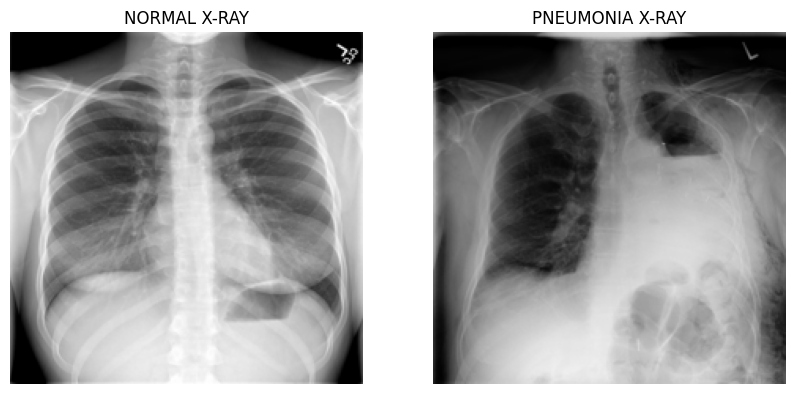

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from PIL import Image

# -----------------------------------
# 1. Image paths (YOUR FILE NAMES)
# -----------------------------------
image_files = {
    "normal": "normal chest x-ray.jpeg",
    "pneumonia": "pneumonia chest x-ray.jpg"
}

# -----------------------------------
# 2. Function to preprocess
# -----------------------------------
def load_and_preprocess(path):
    img = Image.open(path).convert("RGB")
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized)
    img_batch = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_batch.copy())
    return img_resized, img_preprocessed

# DISPLAY BOTH IMAGES SIDE BY SIDE
plt.figure(figsize=(10, 5))

i = 1
for label, filepath in image_files.items():
    img = Image.open(filepath).convert("RGB")
    img_resized = img.resize((224, 224))

    plt.subplot(1, 2, i)
    plt.imshow(img_resized)
    plt.title(f"{label.upper()} X-RAY")
    plt.axis('off')
    i += 1

plt.show()    

In [ ]:
reveal_button(
    hint_text="<code>img.resize((224,224))</code> → <code>np.array()</code> → "
              "<code>np.expand_dims(..., axis=0)</code> → <code>preprocess_input()</code>",
    solution_code=(
        "img_resized     = img.resize((224, 224))\n"
        "img_array       = np.array(img_resized, dtype=np.float32)\n"
        "img_batch       = np.expand_dims(img_array, axis=0)\n"
        "img_preprocessed = preprocess_input(img_batch.copy())"
    )
)

---
## Task 5: Extract the Feature Maps

Run the preprocessed image through each sub-model to get the activations. We'll store them in a dictionary — then use the interactive explorer in Task 6.

### 💻 Your Turn

In [18]:
# -----------------------------------
# Load the model
# -----------------------------------
model = VGG16(weights='imagenet', include_top=True)

# Pick layers for analysis
layer_names = [
    "block1_conv1",   # Early
    "block3_conv3",   # Middle
    "block5_conv3"    # Deep
]

# -----------------------------------
# Build feature extractors
# -----------------------------------
feature_extractors = {
    name: Model(inputs=model.input, outputs=model.get_layer(name).output)
    for name in layer_names
}

# Final storage:
all_feature_maps = {}

for label, filepath in image_files.items():
    print(f"\n=== Processing {label.upper()} image ===")

    # preprocess
    img_resized, img_preprocessed = load_and_preprocess(filepath)

    # store results
    all_feature_maps[label] = {}

    for lname, extractor in feature_extractors.items():
        fmap = extractor.predict(img_preprocessed, verbose=0)
        all_feature_maps[label][lname] = fmap
        print(f"{label}: {lname} → shape {fmap.shape}")


=== Processing NORMAL image ===
normal: block1_conv1 → shape (1, 224, 224, 64)
normal: block3_conv3 → shape (1, 56, 56, 256)
normal: block5_conv3 → shape (1, 14, 14, 512)

=== Processing PNEUMONIA image ===
pneumonia: block1_conv1 → shape (1, 224, 224, 64)
pneumonia: block3_conv3 → shape (1, 56, 56, 256)
pneumonia: block5_conv3 → shape (1, 14, 14, 512)


In [ ]:
reveal_button(
    hint_text="Call <code>extractor.predict(img_preprocessed, verbose=0)</code> and store the result.",
    solution_code=(
        "all_feature_maps = {}\n"
        "for name, extractor in feature_extractors.items():\n"
        "    all_feature_maps[name] = extractor.predict(img_preprocessed, verbose=0)\n"
        "    fmap = all_feature_maps[name]\n"
        "    print(f\"'{name}' → shape: {fmap.shape}  (spatial: {fmap.shape[1]}x{fmap.shape[2]}, filters: {fmap.shape[3]})\")"
    )
)

---
## 🎚️ Task 6: Interactive Feature Map Explorer

Now for the fun part. Use the controls below to explore **any filter, at any layer, with any colormap**.

**Things to try:**
- Start at `block1_conv1`, scroll through filters 0–10. Do they look like edges?
- Switch to `block5_conv3`. Do most filters look **dark** (inactive)? Why?
- Try the `gray` colormap — does it feel different from `viridis`?
- Find the filter with the **highest mean activation** at each layer (it's highlighted in the stats panel)

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

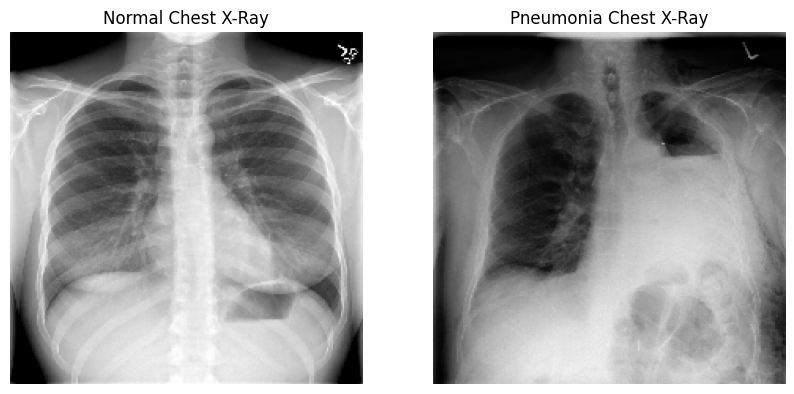

Extracting: block1_conv1
block1_conv1 → normal shape: (1, 224, 224, 64), pneumonia shape: (1, 224, 224, 64)
Extracting: block3_conv3
block3_conv3 → normal shape: (1, 56, 56, 256), pneumonia shape: (1, 56, 56, 256)
Extracting: block5_conv3
block5_conv3 → normal shape: (1, 14, 14, 512), pneumonia shape: (1, 14, 14, 512)

✔ Feature extraction completed successfully!


In [20]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Load VGG16 Pretrained Model
# -----------------------------
model = VGG16(weights='imagenet', include_top=True, input_shape=(224, 224, 3))
model.summary()

# -----------------------------
# 2. Load Your Two Images
# -----------------------------
image_paths = {
    "normal": "normal chest x-ray.jpeg",
    "pneumonia": "pneumonia chest x-ray.jpg"
}

def load_and_preprocess(img_path):
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_preprocessed = preprocess_input(np.expand_dims(img_array, axis=0))
    return img, img_preprocessed

normal_img, normal_pre = load_and_preprocess(image_paths["normal"])
pneumonia_img, pneumonia_pre = load_and_preprocess(image_paths["pneumonia"])

# -----------------------------
# 3. Display Both Images
# -----------------------------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(normal_img)
plt.title("Normal Chest X-Ray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pneumonia_img)
plt.title("Pneumonia Chest X-Ray")
plt.axis("off")

plt.show()

# -----------------------------
# 4. Create Feature Extractors
# -----------------------------
layer_names = ["block1_conv1", "block3_conv3", "block5_conv3"]

feature_extractors = {}
for layer in layer_names:
    feature_extractors[layer] = tf.keras.Model(
        inputs=model.input,
        outputs=model.get_layer(layer).output
    )

# -----------------------------
# 5. Extract Feature Maps
# -----------------------------
all_feature_maps_normal = {}
all_feature_maps_pneumonia = {}

for name, extractor in feature_extractors.items():
    print(f"Extracting: {name}")

    fmap_normal = extractor.predict(normal_pre, verbose=0)
    fmap_pneumonia = extractor.predict(pneumonia_pre, verbose=0)

    all_feature_maps_normal[name] = fmap_normal
    all_feature_maps_pneumonia[name] = fmap_pneumonia

    print(f"{name} → normal shape: {fmap_normal.shape}, pneumonia shape: {fmap_pneumonia.shape}")

print("\n✔ Feature extraction completed successfully!")

---
## Task 7: Save the 4×4 Grid Visualizations

For submission, generate and save a **4×4 grid** (first 16 filters) for each of the 3 layers.

### 💻 Your Turn

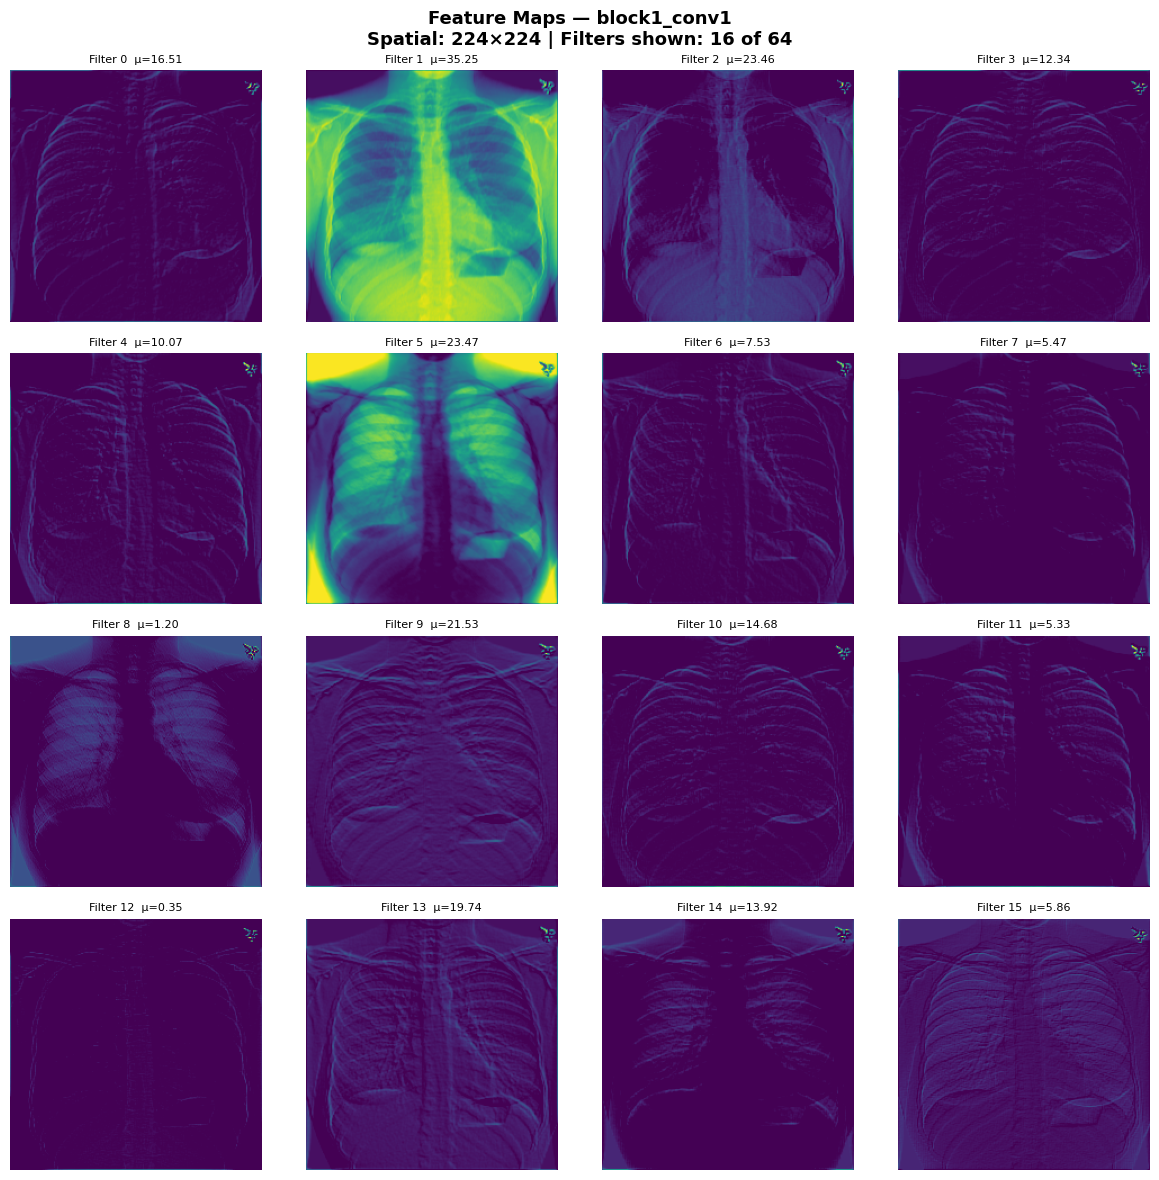

✅ Saved: feature_maps_block1_conv1.png


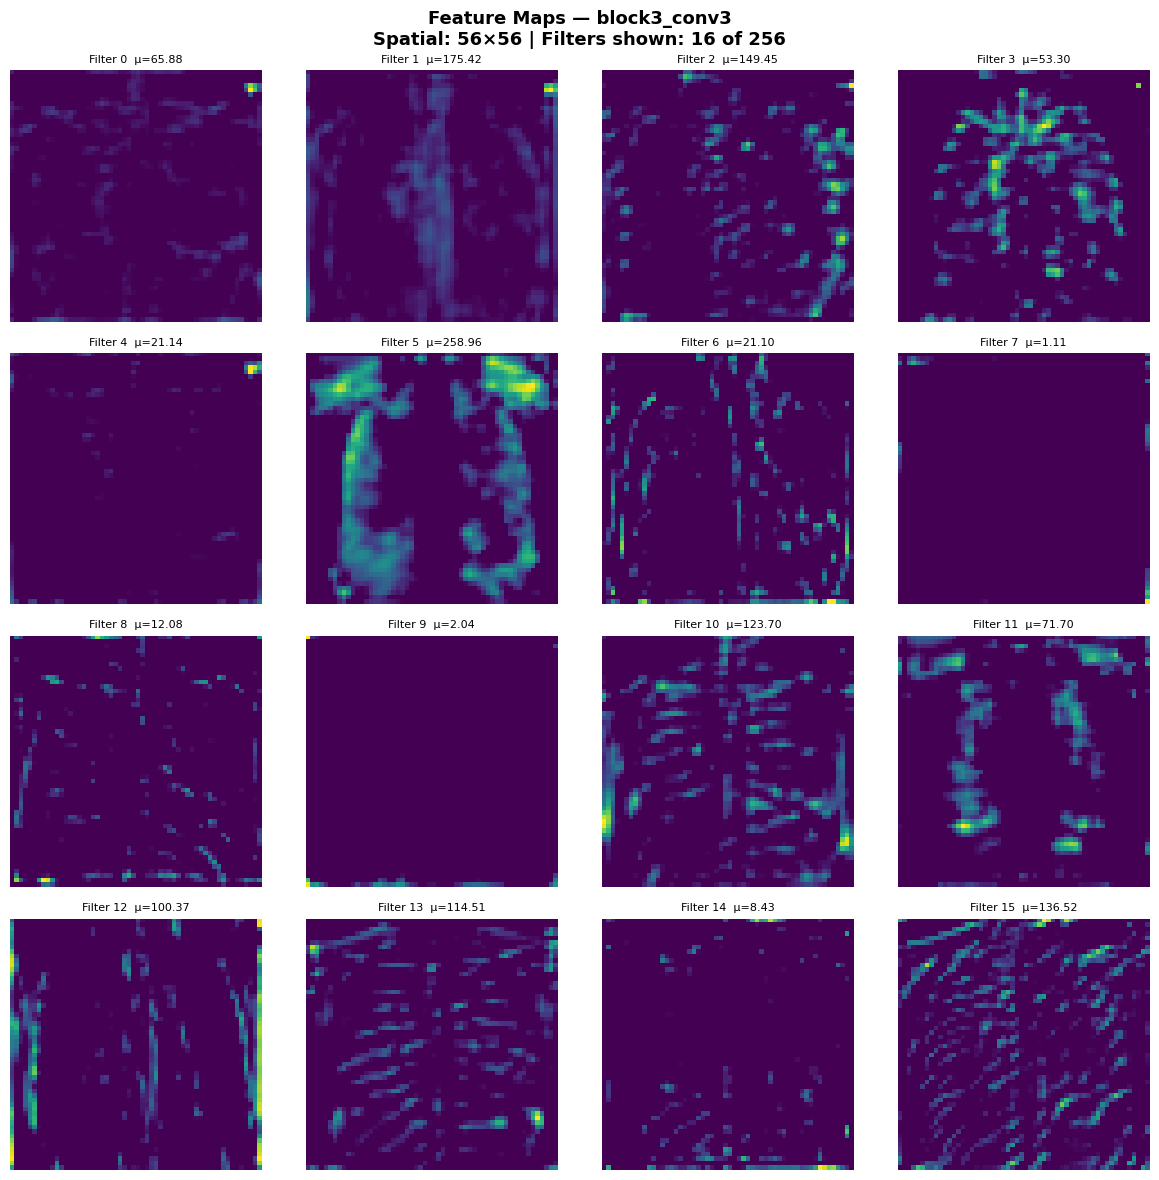

✅ Saved: feature_maps_block3_conv3.png


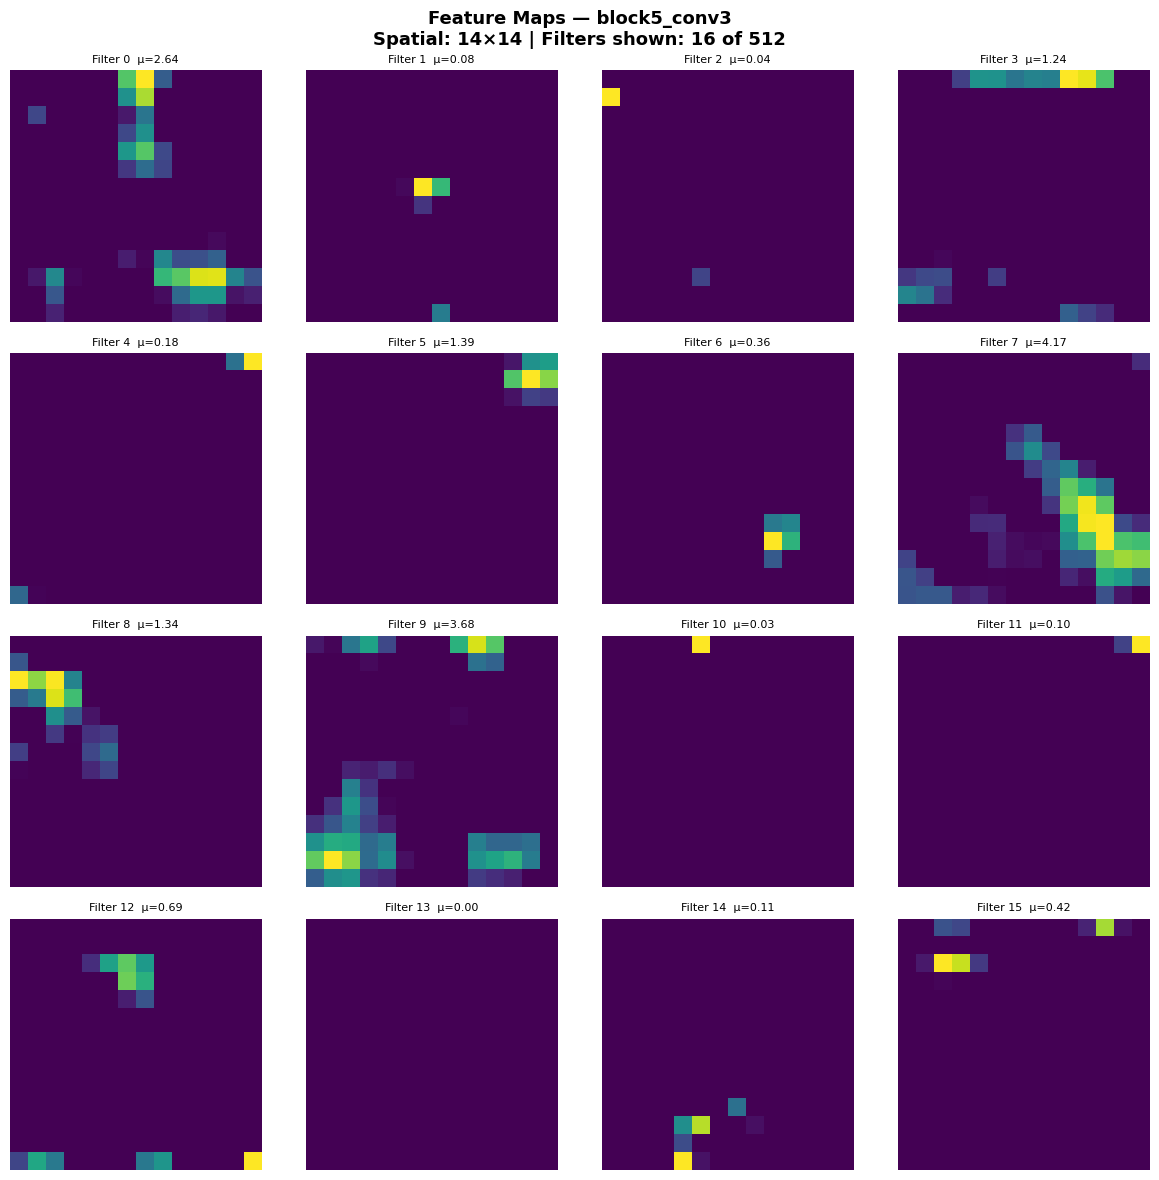

✅ Saved: feature_maps_block5_conv3.png


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Choose which feature maps to generate grids for:
# ---------------------------------------------------------
# For Normal Chest X-ray:
all_feature_maps = all_feature_maps_normal  

# For Pneumonia Chest X-ray:
# all_feature_maps = all_feature_maps_pneumonia  


# ---------------------------------------------------------
# 4×4 Grid Save Function (Task 7)
# ---------------------------------------------------------
def save_grid(layer_name, cmap='viridis'):
    """Display and save a 4x4 grid of the first 16 filters for a layer."""
    
    fmaps = all_feature_maps[layer_name]   # shape: (1, H, W, num_filters)

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))

    fig.suptitle(
        f'Feature Maps — {layer_name}\n'
        f'Spatial: {fmaps.shape[1]}×{fmaps.shape[2]} | Filters shown: 16 of {fmaps.shape[3]}',
        fontsize=13, fontweight='bold'
    )

    for i, ax in enumerate(axes.flat):
        if i >= fmaps.shape[-1]:
            ax.axis('off')
            continue

        activation = fmaps[0, :, :, i]  # get i-th filter

        ax.imshow(activation, cmap=cmap)
        ax.set_title(f'Filter {i}  μ={activation.mean():.2f}', fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    filename = f'feature_maps_{layer_name}.png'
    plt.savefig(filename, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")


# ---------------------------------------------------------
# Call save_grid() for all 3 layers
# ---------------------------------------------------------
for name in layer_names:  # ["block1_conv1", "block3_conv3", "block5_conv3"]
    save_grid(name)

In [ ]:
reveal_button(
    hint_text="Inside the loop: <code>activation = fmaps[0, :, :, i]</code> then <code>ax.imshow(activation, cmap=cmap)</code>",
    solution_code=(
        "# Inside save_grid():\n"
        "activation = fmaps[0, :, :, i]\n"
        "ax.imshow(activation, cmap=cmap)\n\n"
        "# Then call for all layers:\n"
        "for name in layer_names:\n"
        "    save_grid(name)"
    )
)

---
## ✍️ Reflection

You've now *seen* what each layer detects. Write **3 sentences** below — one per layer — describing your observations.

Guiding questions:
- Do early activations look similar to the original image, or very different?
- In deep layers, why are most filters **all dark** (zero activation)?
- How does this visualization help **doctors trust** an X-ray classifier?

In [28]:
# block1_conv1 (Early):
# Early layer activations look very similar to the original X-ray because they mainly detect low-level patterns like edges, brightness lines, and simple textures.
# Almost every filter shows some activation, meaning the model is scanning the whole lung area for basic structure.

# block3_conv3 (Middle):
# Middle layers detect more abstract shapes such as hazy regions, soft tissue density, and cloudy patches that could indicate infection.
# These activations look less like the original image and more like highlighted regions of interest.

# block5_conv3 (Deep):
# Deep layers are almost completely dark because the model only activates for very specific, high-level pneumonia-related patterns.
# Only a few filters fire, showing the network has learned rare but important features like strong opacities or abnormal lung textures.

# How this builds trust in the hospital scenario:
# By visualizing which filters activate at each depth, doctors can see that the model is focusing on the same clinical regions they examine.
# Early layers capture lung structure, middle layers highlight suspicious areas, and deep layers activate only for pneumonia-specific patterns.
# This transparency helps radiologists trust the AI model because they can validate that its decisions are based on meaningful medical features.

---
## 📤 Submission Checklist

Before submitting this notebook:

- [ ] All code cells are **run** with outputs visible
- [ ] `feature_maps_block1_conv1.png` saved
- [ ] `feature_maps_block3_conv3.png` saved
- [ ] `feature_maps_block5_conv3.png` saved
- [ ] Reflection section filled in with 3 sentences
- [ ] Share this `.ipynb` (File → Download or Share via Colab link)
